# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [17]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [18]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w252_s5"
FORWARD_DAYS = 252
DATASET = 'train'  # 'train', 'val', 'test' or 'all'
dataset_dir = results_root / DATASET_NAME / f'{FORWARD_DAYS}_days_gap'
analysis_dir = dataset_dir / f"reconstruction_analysis_{DATASET}"
comparison_dir = dataset_dir / f"comparison_{DATASET}"
comparison_dir.mkdir(parents=True, exist_ok=True)

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (15): ['AE_100dim_0001', 'AE_10dim_0001', 'AE_20dim_0001', 'AE_3dim_0001', 'AE_50dim_0001', 'linearAE_100dim_0001', 'linearAE_10dim_0001', 'linearAE_20dim_0001', 'linearAE_3dim_0001', 'linearAE_50dim_0001', 'PCA_100dim', 'PCA_10dim', 'PCA_20dim', 'PCA_3dim', 'PCA_50dim']


In [19]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / f"reconstruction_errors_{DATASET}.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction_analysis_train/AE_100dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction_analysis_train/AE_10dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction_analysis_train/AE_20dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction_analysis_train/AE_3dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction_analysis_train/AE_50dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/252_days_gap/reconstruction

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_3dim,0.004307,0.001256,0.002278,0.004131,0.009450,0.051165,0.007545,0.036829,0.050910,0.077759,6.498111,0.921468,4.772894,6.427380,9.721037,614.0,41.636232,6.694700,20.202020,37.373737,41.414141,45.454545,60.606061,614.0,26.516955,...,10.100808,614.0,5.702345,0.563254,4.791111,5.208485,5.654141,6.127273,7.805455,614.0,0.688535,0.625661,0.000000,0.249848,0.501515,0.924848,4.193131,614.0,51.058632,13.274114,10.0,40.0,50.0,60.0,80.0
PCA_10dim,0.001472,0.000706,0.000448,0.001334,0.004864,0.029093,0.007231,0.015256,0.028785,0.055545,3.736859,0.871656,2.116306,3.652680,6.974183,614.0,59.102425,7.240558,34.343434,54.545455,59.595960,63.636364,79.797980,614.0,42.316659,...,10.100808,614.0,5.720558,0.657628,4.364040,5.157222,5.699899,6.187778,7.421414,614.0,0.632752,0.587802,0.001414,0.216111,0.474141,0.892121,4.133737,614.0,63.338762,13.830454,20.0,50.0,60.0,70.0,100.0
PCA_20dim,0.000487,0.000166,0.000158,0.000468,0.001379,0.016800,0.002914,0.009442,0.016753,0.029167,2.176583,0.364804,1.256814,2.163739,3.713599,614.0,72.909881,5.704801,51.515152,68.686869,72.727273,76.767677,89.898990,614.0,57.685771,...,10.100808,614.0,5.973499,0.838489,4.563636,5.260707,5.843737,6.518131,9.417778,614.0,0.444101,0.380822,0.002626,0.135505,0.353333,0.650101,2.113939,614.0,72.508143,13.823489,20.0,60.0,70.0,80.0,100.0
PCA_50dim,0.000152,0.000072,0.000024,0.000139,0.000499,0.009260,0.002102,0.003740,0.009150,0.017104,1.203339,0.277236,0.485472,1.180281,2.233779,614.0,83.137565,5.012037,61.616162,79.797980,83.838384,86.868687,93.939394,614.0,71.449002,...,10.100808,614.0,6.012372,0.792383,4.394141,5.543283,5.972828,6.411111,9.511919,614.0,0.318200,0.325805,0.000808,0.102879,0.209596,0.431010,2.203838,614.0,81.465798,12.216160,40.0,70.0,80.0,90.0,100.0
PCA_100dim,0.000061,0.000026,0.000011,0.000057,0.000147,0.005826,0.001242,0.002602,0.005779,0.009198,0.761517,0.165951,0.337104,0.753977,1.210445,614.0,88.494061,3.944136,73.737374,85.858586,88.888889,90.909091,98.989899,614.0,79.583905,...,10.100808,614.0,6.039572,0.786626,4.628889,5.510101,5.972727,6.468232,9.383232,614.0,0.269199,0.273952,0.000404,0.082929,0.183333,0.356515,1.603434,614.0,84.951140,11.785781,40.0,80.0,90.0,90.0,100.0
linearAE_3dim_0001,0.005151,0.001056,0.002375,0.005184,0.009425,0.056166,0.005949,0.038086,0.056731,0.077478,7.139813,0.730401,4.873411,7.200147,9.708245,614.0,38.732603,6.564078,22.222222,34.343434,37.373737,43.434343,55.555556,614.0,24.226999,...,10.100808,614.0,5.629349,0.618274,4.249091,5.158586,5.617576,6.093131,7.040

In [20]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

def reshape_to_matrix(series_or_df, metric_name):
    if isinstance(series_or_df, pd.DataFrame):
        df_temp = series_or_df[[metric_name]].copy()
    else:
        df_temp = series_or_df.to_frame(name=metric_name)

    df_flat = df_temp.reset_index()
    model_col = "model" if "model" in df_flat.columns else df_flat.columns[0]
    df_flat[["method", "K"]] = df_flat[model_col].apply(
        lambda x: pd.Series(parse_model_name(x))
    )
    df_flat["K"] = pd.to_numeric(df_flat["K"], errors="coerce")
    df_flat = df_flat.dropna(subset=["method", "K"]).copy()

    # If multiple runs exist for the same method/K, average them.
    grouped = (
        df_flat.groupby(["method", "K"], as_index=False)[metric_name]
        .mean()
    )
    matrix_df = grouped.pivot(index="method", columns="K", values=metric_name)

    ordered_methods = [m for m in method_order if m in matrix_df.index]
    ordered_methods += [m for m in matrix_df.index if m not in ordered_methods]
    matrix_df = matrix_df.reindex(ordered_methods)
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns), axis=1)
    return matrix_df

def combine_mean_std(means_df, stds_df, metric_name, precision=2):
    mean_mat = reshape_to_matrix(means_df, metric_name)
    std_mat = reshape_to_matrix(stds_df, metric_name)
    mean_mat, std_mat = mean_mat.align(std_mat)

    def fmt(m, s):
        if pd.isna(m):
            return np.nan
        mean_str = f"{m:.{precision}e}"
        if pd.isna(s):
            return mean_str
        std_str = f"{s:.{precision}e}"
        return f"{mean_str} +/- {std_str}"

    combined = mean_mat.astype(object)
    for row in mean_mat.index:
        for col in mean_mat.columns:
            combined.loc[row, col] = fmt(mean_mat.loc[row, col], std_mat.loc[row, col])
    return combined

for metric in available_err_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(err_means, err_stds, metric)
    display(combined)
    out_path = comparison_dir / f"err_{metric}_mean_std.csv"
    combined.to_csv(out_path)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)


 METRICA: MSE


K,3,10,20,50,100
method,,,,,
PCA,4.31e-03 +/- 1.26e-03,1.47e-03 +/- 7.06e-04,4.87e-04 +/- 1.66e-04,1.52e-04 +/- 7.18e-05,6.07e-05 +/- 2.61e-05
linearAE,5.15e-03 +/- 1.06e-03,1.77e-03 +/- 8.27e-04,5.48e-04 +/- 1.91e-04,2.62e-04 +/- 1.02e-04,2.54e-04 +/- 9.77e-05
AE,7.80e-04 +/- 3.56e-04,6.18e-04 +/- 2.73e-04,5.95e-04 +/- 2.12e-04,4.34e-04 +/- 1.84e-04,5.10e-04 +/- 2.19e-04



 METRICA: MAE


K,3,10,20,50,100
method,,,,,
PCA,5.12e-02 +/- 7.54e-03,2.91e-02 +/- 7.23e-03,1.68e-02 +/- 2.91e-03,9.26e-03 +/- 2.10e-03,5.83e-03 +/- 1.24e-03
linearAE,5.62e-02 +/- 5.95e-03,3.22e-02 +/- 7.44e-03,1.78e-02 +/- 3.09e-03,1.22e-02 +/- 2.33e-03,1.20e-02 +/- 2.30e-03
AE,2.15e-02 +/- 4.74e-03,1.90e-02 +/- 4.49e-03,1.88e-02 +/- 3.41e-03,1.59e-02 +/- 3.27e-03,1.75e-02 +/- 3.79e-03



 METRICA: Frobenius


K,3,10,20,50,100
method,,,,,
PCA,6.50e+00 +/- 9.21e-01,3.74e+00 +/- 8.72e-01,2.18e+00 +/- 3.65e-01,1.20e+00 +/- 2.77e-01,7.62e-01 +/- 1.66e-01
linearAE,7.14e+00 +/- 7.30e-01,4.11e+00 +/- 9.18e-01,2.31e+00 +/- 3.84e-01,1.59e+00 +/- 3.04e-01,1.57e+00 +/- 2.99e-01
AE,2.73e+00 +/- 5.89e-01,2.43e+00 +/- 5.29e-01,2.40e+00 +/- 4.30e-01,2.04e+00 +/- 4.14e-01,2.21e+00 +/- 4.57e-01


In [21]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)
mst_stds = pd.DataFrame(index=stats_df.index)
for m in available_mst_metrics:
    std_col = f"mst_{m}_std"
    if std_col in stats_df.columns:
        mst_stds[m] = stats_df[std_col]
    else:
        mst_stds[m] = np.nan

for metric in available_mst_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(mst_means, mst_stds, metric)
    display(combined)
    out_path = comparison_dir / f"mst_{metric}_mean_std.csv"
    combined.to_csv(out_path)


 METRICA: edge_overlap_pct


K,3,10,20,50,100
method,,,,,
PCA,4.16e+01 +/- 6.69e+00,5.91e+01 +/- 7.24e+00,7.29e+01 +/- 5.70e+00,8.31e+01 +/- 5.01e+00,8.85e+01 +/- 3.94e+00
linearAE,3.87e+01 +/- 6.56e+00,5.55e+01 +/- 8.29e+00,7.18e+01 +/- 5.85e+00,7.90e+01 +/- 5.09e+00,7.92e+01 +/- 5.30e+00
AE,7.31e+01 +/- 6.56e+00,7.52e+01 +/- 5.80e+00,7.57e+01 +/- 5.50e+00,7.79e+01 +/- 5.62e+00,7.80e+01 +/- 5.30e+00



 METRICA: edge_jaccard_pct


K,3,10,20,50,100
method,,,,,
PCA,2.65e+01 +/- 5.35e+00,4.23e+01 +/- 7.22e+00,5.77e+01 +/- 7.09e+00,7.14e+01 +/- 7.20e+00,7.96e+01 +/- 6.27e+00
linearAE,2.42e+01 +/- 5.16e+00,3.89e+01 +/- 7.99e+00,5.63e+01 +/- 7.12e+00,6.56e+01 +/- 6.86e+00,6.59e+01 +/- 7.19e+00
AE,5.80e+01 +/- 8.10e+00,6.06e+01 +/- 7.43e+00,6.13e+01 +/- 7.11e+00,6.42e+01 +/- 7.51e+00,6.43e+01 +/- 7.12e+00



 METRICA: degree_l1


...

K,3,10,20,50,100
method,,,,,
PCA,5.85e-01 +/- 5.37e-01,4.91e-01 +/- 4.76e-01,3.45e-01 +/- 3.05e-01,2.48e-01 +/- 2.54e-01,2.07e-01 +/- 2.08e-01
linearAE,5.50e-01 +/- 5.38e-01,5.52e-01 +/- 5.39e-01,3.08e-01 +/- 2.75e-01,2.79e-01 +/- 2.55e-01,2.63e-01 +/- 2.47e-01
AE,3.53e-01 +/- 3.28e-01,3.23e-01 +/- 2.74e-01,3.40e-01 +/- 2.91e-01,2.82e-01 +/- 2.53e-01,3.10e-01 +/- 2.72e-01



 METRICA: avg_path_len_unweighted_diff


K,3,10,20,50,100
method,,,,,
PCA,6.89e-01 +/- 6.26e-01,6.33e-01 +/- 5.88e-01,4.44e-01 +/- 3.81e-01,3.18e-01 +/- 3.26e-01,2.69e-01 +/- 2.74e-01
linearAE,7.34e-01 +/- 6.43e-01,7.03e-01 +/- 6.70e-01,4.04e-01 +/- 3.42e-01,3.64e-01 +/- 3.29e-01,3.44e-01 +/- 3.11e-01
AE,4.19e-01 +/- 4.02e-01,3.92e-01 +/- 3.43e-01,4.17e-01 +/- 3.69e-01,3.62e-01 +/- 3.19e-01,3.96e-01 +/- 3.37e-01



 METRICA: betweenness_topk_overlap_pct


K,3,10,20,50,100
method,,,,,
PCA,5.11e+01 +/- 1.33e+01,6.33e+01 +/- 1.38e+01,7.25e+01 +/- 1.38e+01,8.15e+01 +/- 1.22e+01,8.50e+01 +/- 1.18e+01
linearAE,4.94e+01 +/- 1.38e+01,6.14e+01 +/- 1.28e+01,7.29e+01 +/- 1.30e+01,7.92e+01 +/- 1.25e+01,7.93e+01 +/- 1.21e+01
AE,7.28e+01 +/- 1.38e+01,7.41e+01 +/- 1.32e+01,7.36e+01 +/- 1.34e+01,7.78e+01 +/- 1.24e+01,7.65e+01 +/- 1.25e+01


# K-based comparison plots
Build plots for error metrics across K and methods.

In [22]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE", "AE", "VAE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE": "LinearAE",
    "AE": "AE",
    "VAE": "VAE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE": "tab:green",
    "AE": "tab:red",
    "VAE": "tab:orange",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE']
K values: [np.int64(3), np.int64(10), np.int64(20), np.int64(50), np.int64(100)]


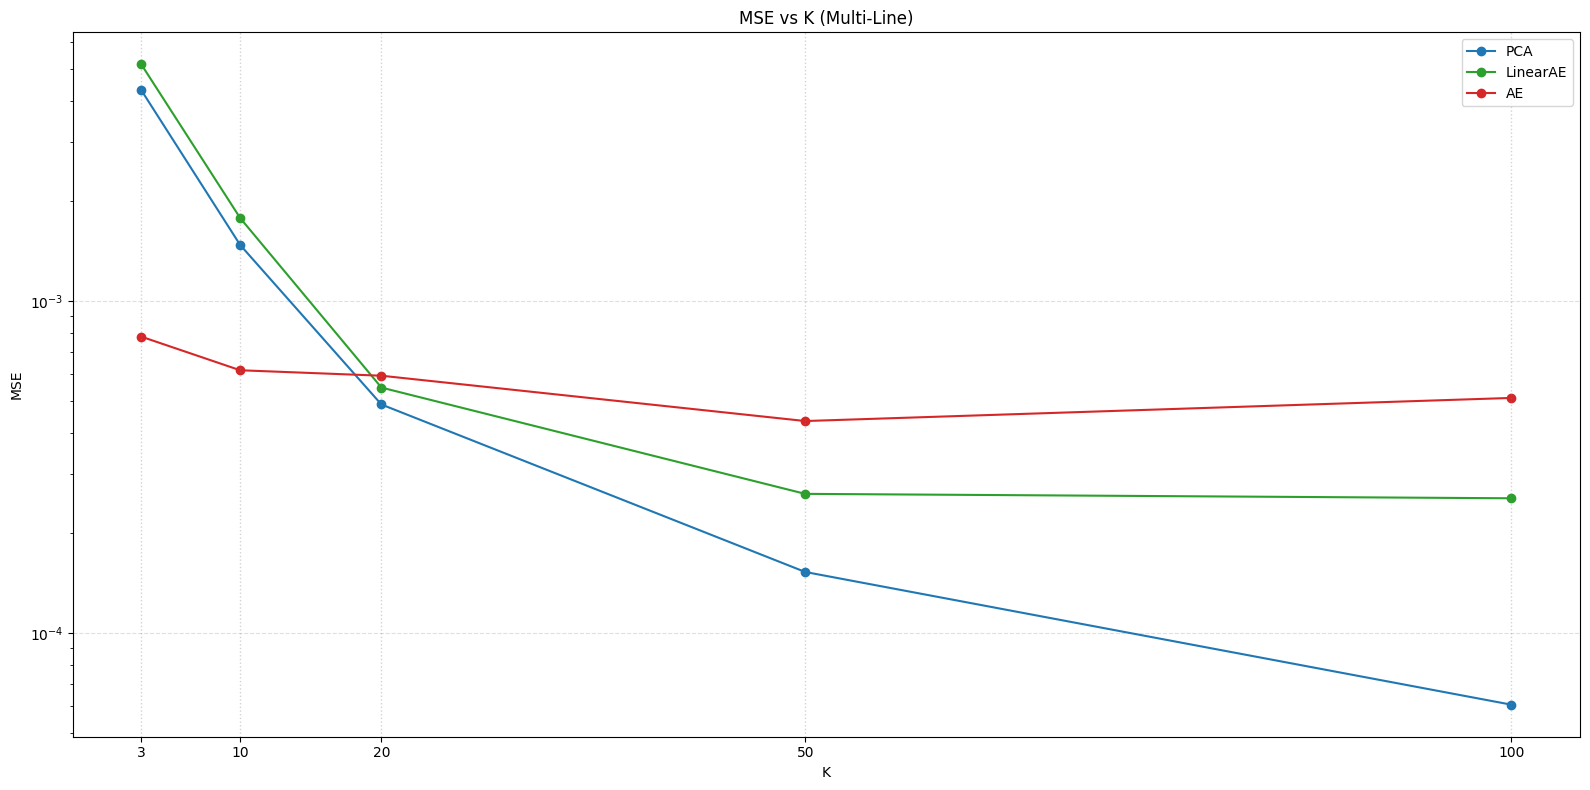

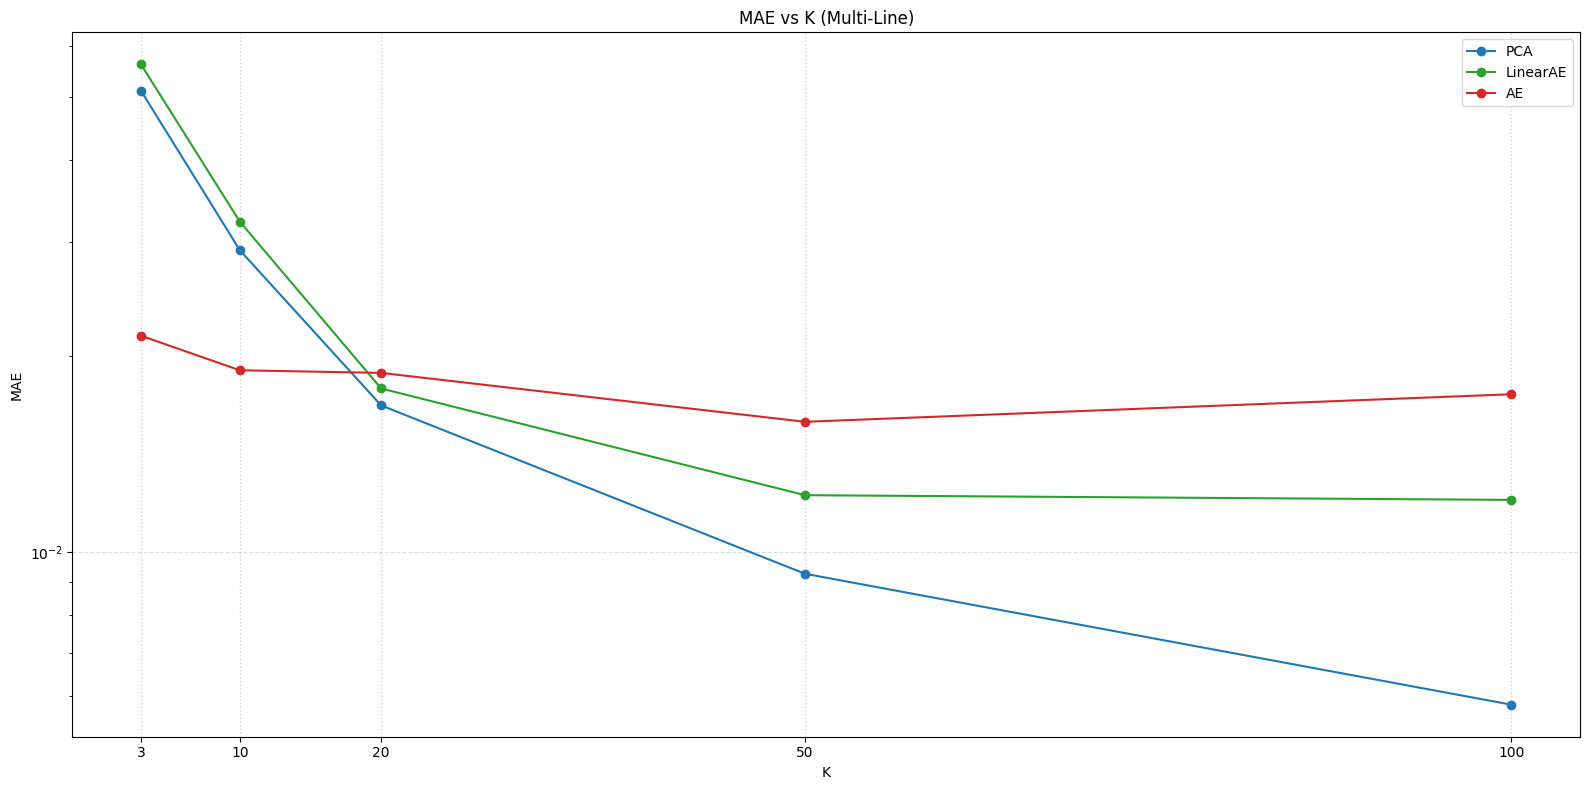

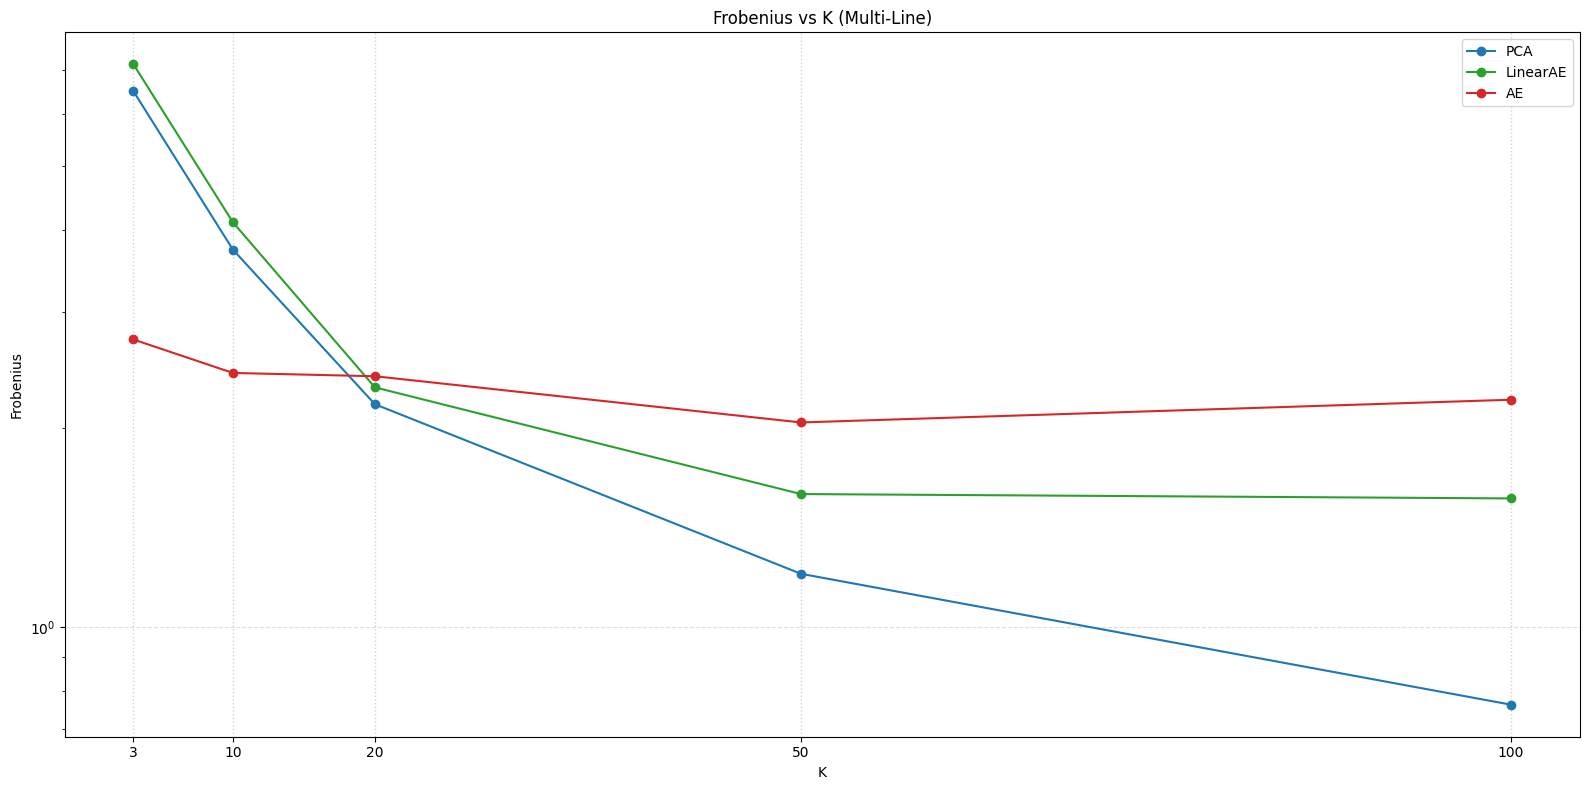

In [23]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"err_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

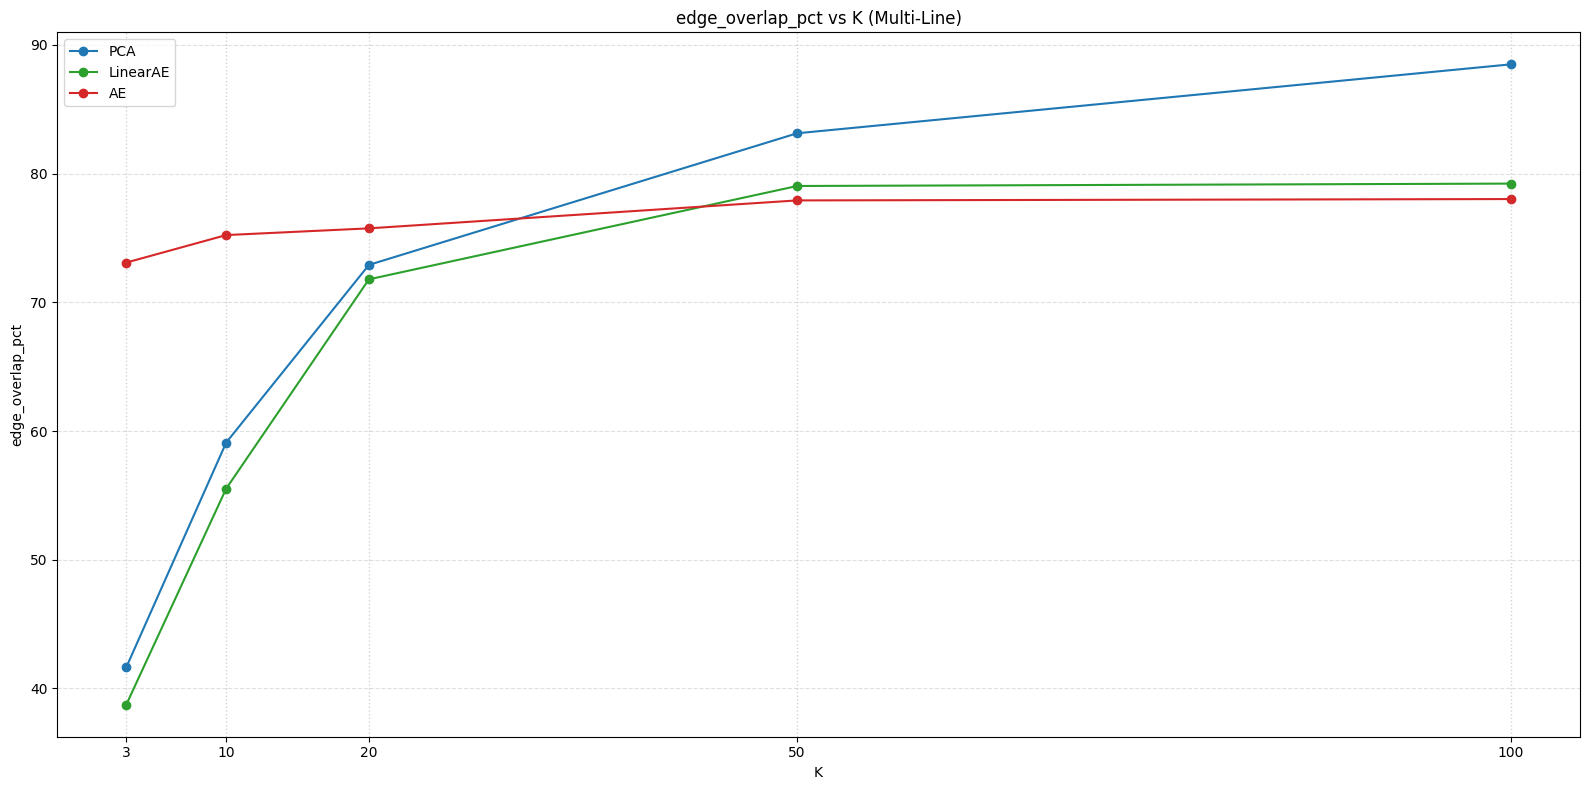

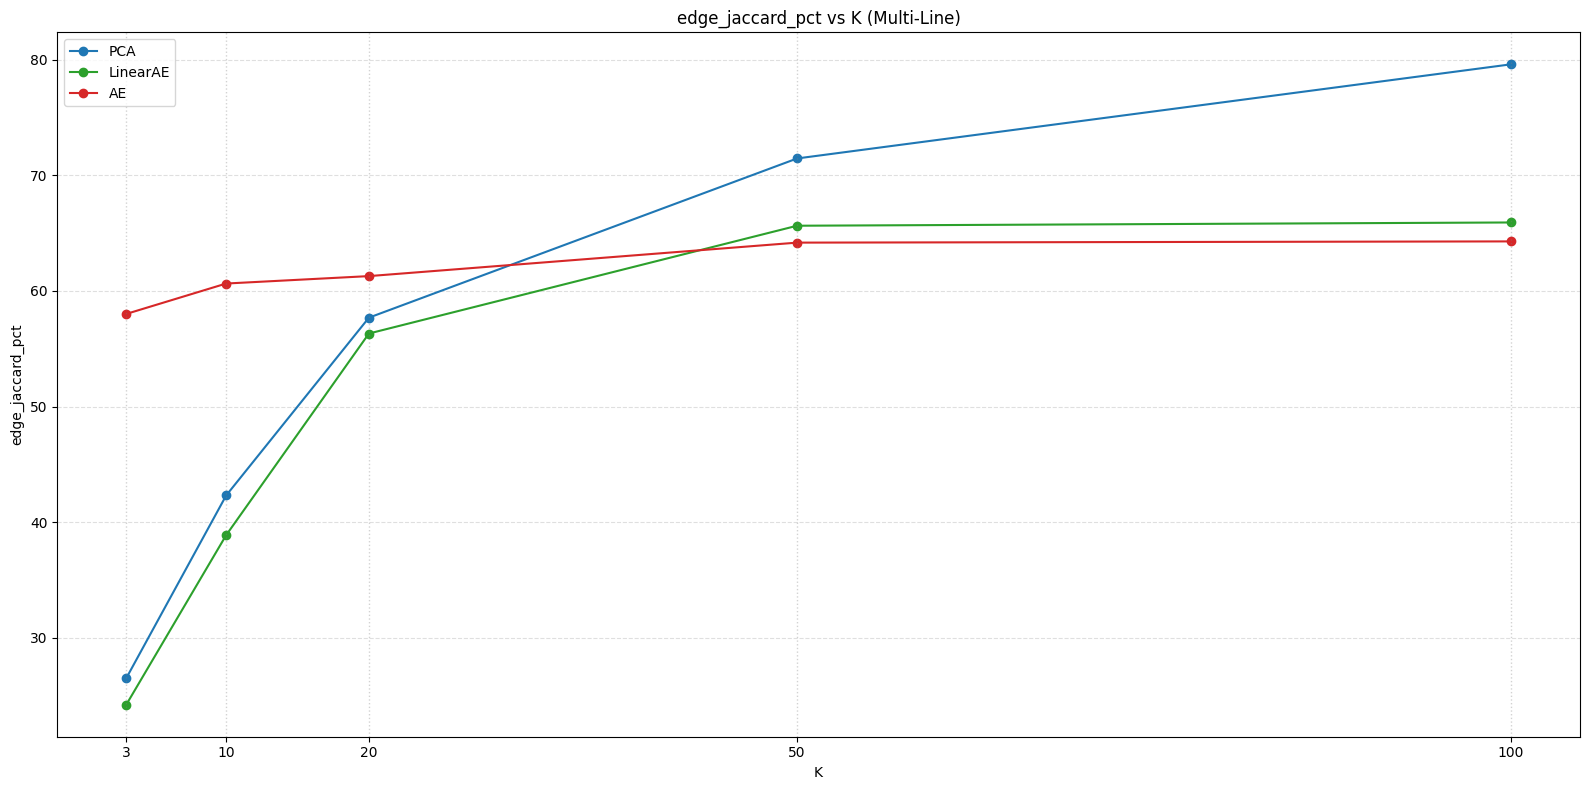

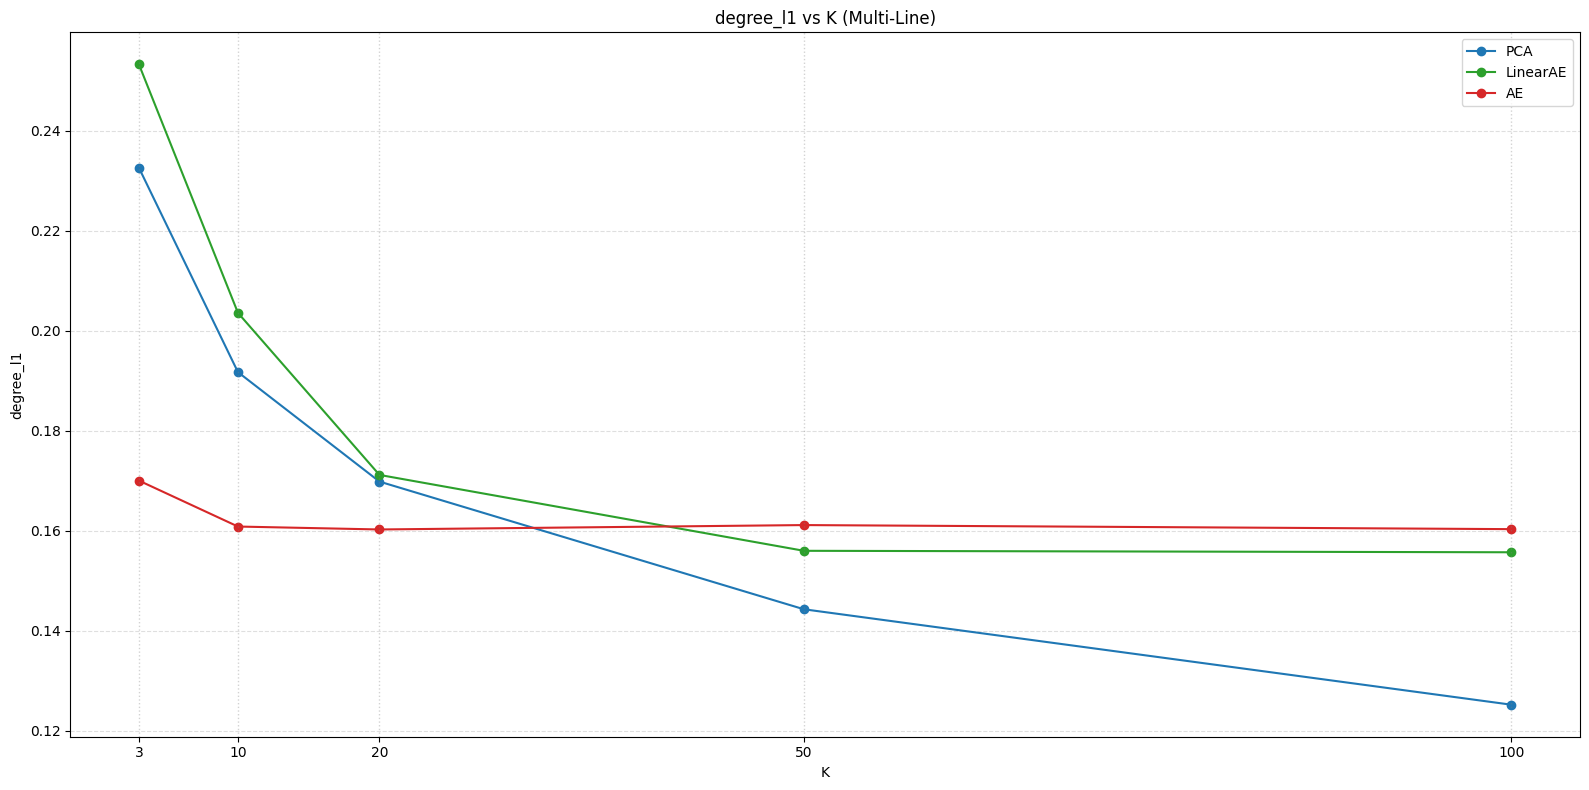

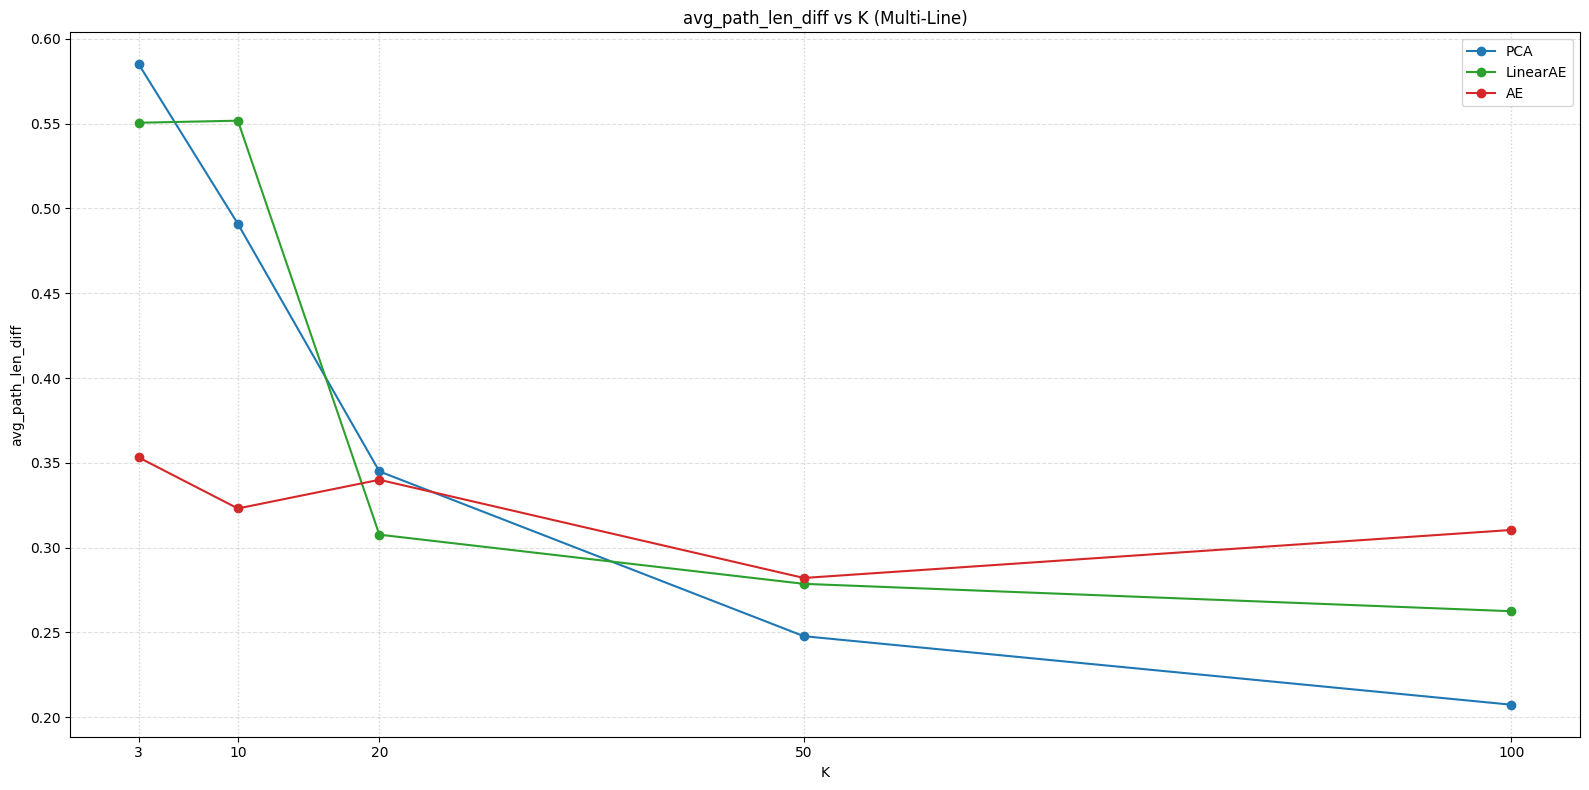

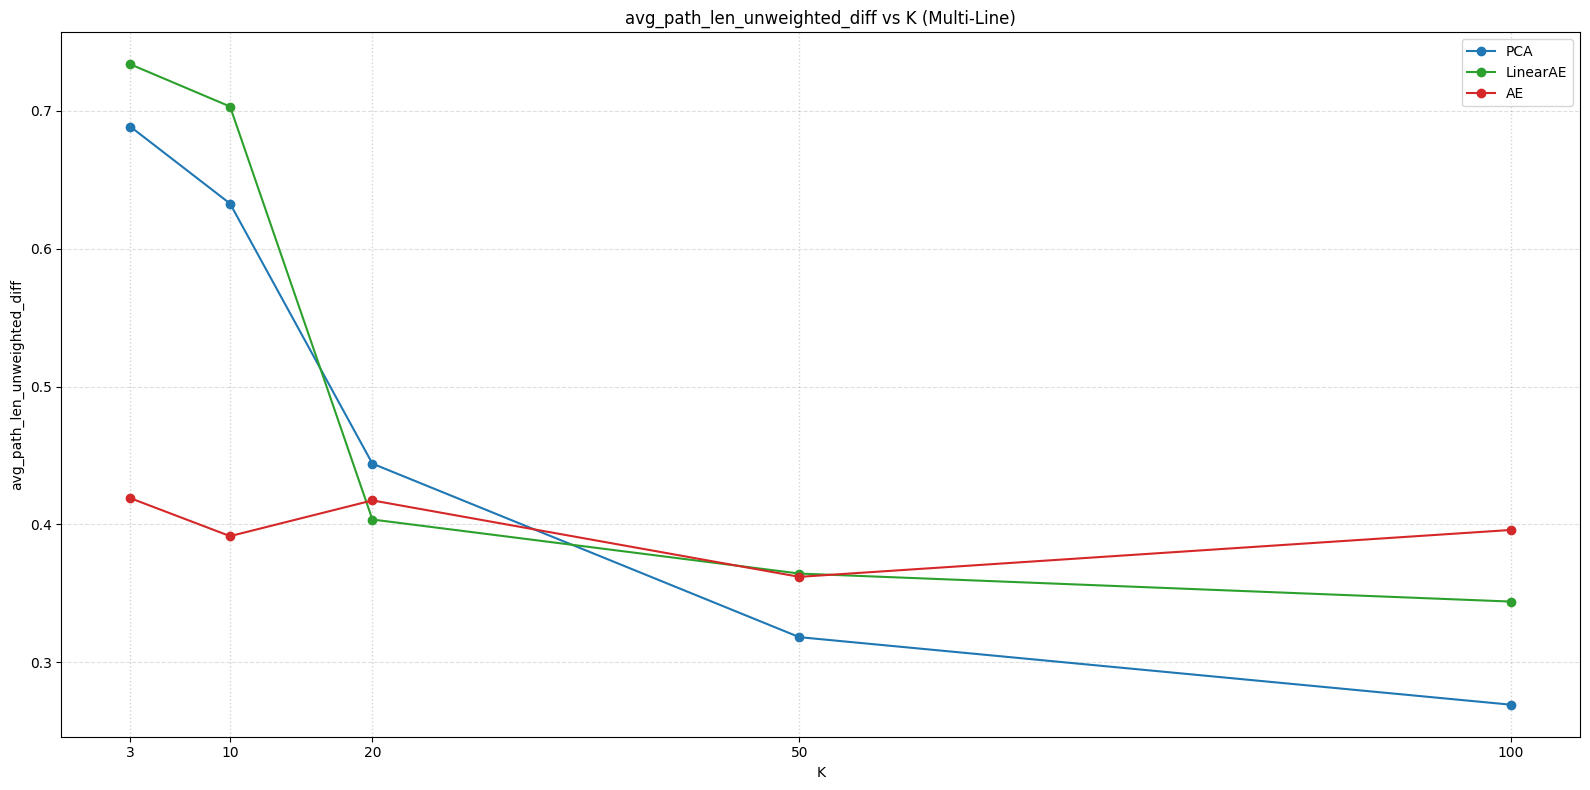

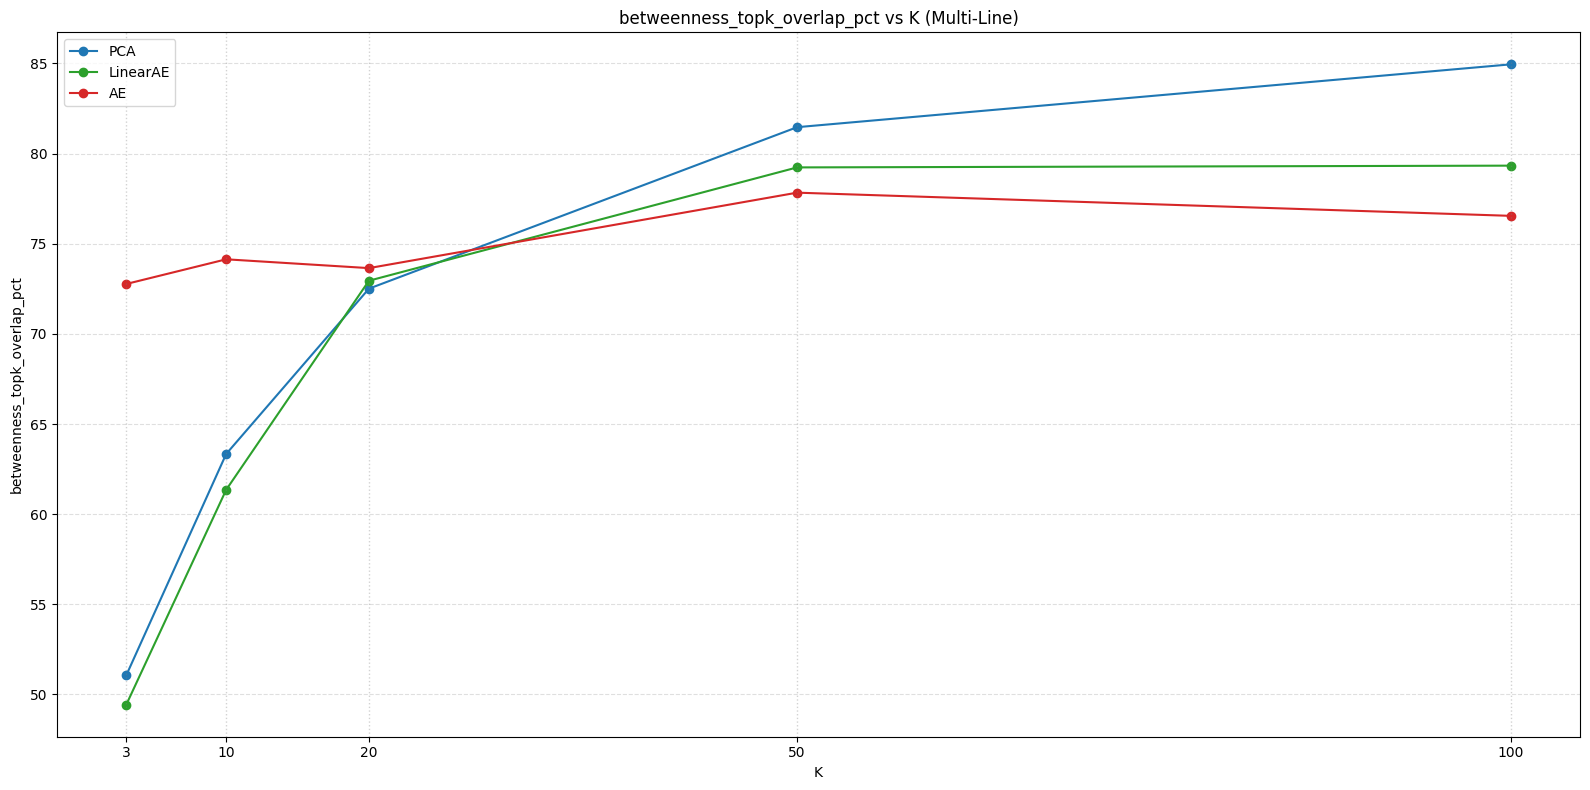

In [24]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"mst_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()